In [2]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('creditcard.csv')

# 2. View the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# 3. Check for any missing values (Crucial first step!)
print("\nMissing values in each column:")
print(df.isnull().sum().max()) # If this prints 0, the data is clean!

# 4. Check the exact count of Fraud vs Valid transactions
print("\nClass distribution (0 = Valid, 1 = Fraud):")
print(df['Class'].value_counts())

First 5 rows of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Missing values in each column:
0

Class distribution (0 = Valid, 1 = Fraud):
Class
0    284315
1       492
Name: count, dtype: int64


C:\Users\sahun\AppData\Local\Temp\ipykernel_15576\1809445703.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='pastel')


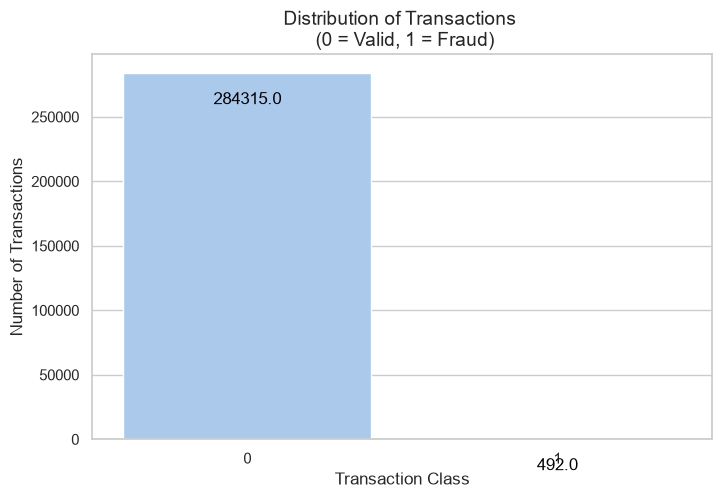

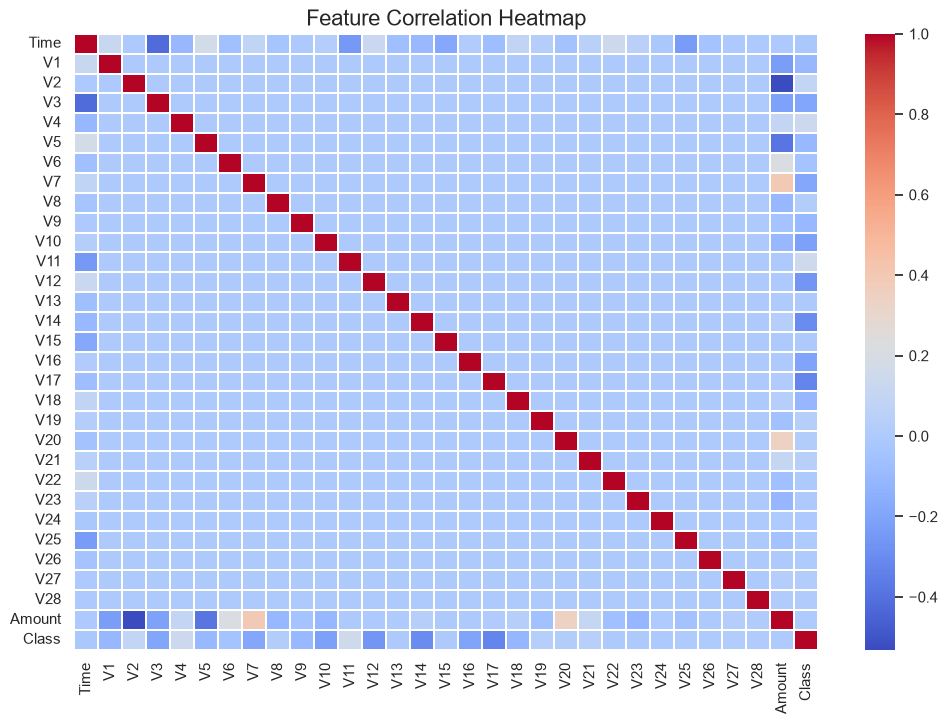

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for our graphs
sns.set_theme(style="whitegrid")

# ---------------------------------------------------
# Graph 1: The Class Imbalance Bar Chart
# ---------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='pastel')
plt.title('Distribution of Transactions \n (0 = Valid, 1 = Fraud)', fontsize=14)
plt.xlabel('Transaction Class', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Adding the exact numbers on top of the bars for clarity
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}', (p.get_x()+0.4, p.get_height()), ha='center', va='top', color='black', size=12)
plt.show()

# ---------------------------------------------------
# Graph 2: Correlation Heatmap
# ---------------------------------------------------
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
# We use a heatmap to see which features are most correlated with Fraud
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.1)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import joblib
import pandas as pd

# Load data again just in case your notebook restarted
df = pd.read_csv('creditcard.csv')

# 1. Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Balance the data using SMOTE
print("Balancing data... (This takes a moment)")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 4. Train the Model
print("Training model... (Please wait 1-2 minutes)")
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train_resampled, y_train_resampled)

# 5. Create the .pkl file!
joblib.dump(model, 'fraud_model.pkl')
print("SUCCESS! Look at your file explorer on the left, the .pkl file is now there!")

Balancing data... (This takes a moment)
Training model... (Please wait 1-2 minutes)
SUCCESS! Look at your file explorer on the left, the .pkl file is now there!


In [5]:
from sklearn.linear_model import LogisticRegression
import joblib

# Training a second model: Logistic Regression
print("Training Logistic Regression model...")
# Hum wahi purana SMOTE wala balanced data use kar rahe hain
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

# Saving the second model
joblib.dump(lr_model, 'logistic_model.pkl')
print("Success! 'logistic_model.pkl' has been created. Check your VS Code Explorer!")


Training Logistic Regression model...
Success! 'logistic_model.pkl' has been created. Check your VS Code Explorer!


c:\Users\sahun\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
